In [348]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np
a_stock = pd.read_csv('stock_spot_china_a.csv')[['证券代码','一级行业','二级行业','三级行业']]

In [67]:
tuple(a_stock[a_stock['一级行业'].isin(['金融'])]['二级行业'].unique())

('房地产', '非银金融', '贵金属', '银行')

In [17]:
def prepare_raw(source):
    df = pd.read_excel(source + '.xlsx') 
    df = df.dropna(subset = ['证券名称']).replace('——',np.nan).dropna(how = 'all').dropna(axis = 1, how = 'all').fillna(0)
    df.columns = [x.replace('\n[报告类型]合并报表\n[单位]元','').replace('\n[报告期]','').replace(source,'') for x in df.columns.tolist()]
    df.columns = [x.replace('年一季','0331').replace('年二季/中报','0630').replace('年三季','0930').replace('年年报','1231') for x in df.columns.tolist()]
    df = a_stock.merge(df, on = '证券代码', how= 'left').drop(columns = ['证券代码','证券名称'])
    return df

capex = prepare_raw('资本支出')
inventory = prepare_raw('存货')
income = prepare_raw('营业收入')

In [50]:
start_date = '2004-01-01'
industry_level = '二级行业'
industry_name = '汽车整车'

def calculate_change(df):
    df = df[df[industry_level].isin([industry_name])].groupby([industry_level]).sum().T/100000000
    df.index = pd.to_datetime(df.index)
    df = df[(df.index > start_date)].sum(axis=1)
    df = ((df - df.shift(4)) / df.shift(4)).dropna(how='all')
    return df

capex_df = calculate_change(capex)
inventory_df = calculate_change(inventory)
income_df = calculate_change(income)
df = pd.concat([capex_df, inventory_df, income_df], axis=1).rename(columns={0: "资本支出", 1: "存货", 2:"营业收入"}).round(2)

In [69]:
import plotly.express as px


historical_percentile = (inventory_df.tail(1)[0] - inventory_df.min()) / (inventory_df.max() - inventory_df.min())

fig = px.line(df, color_discrete_sequence = ['red','yellow','lightgreen'], title = industry_name+'行业库存周期 - 历史分位值:'+ "{:.0%}".format(historical_percentile) ,
              labels={
                     "value": "同比增长率",
                     "index": "",
                     "variable": ""
                 },)
def fig_render(fig):
    fig.update_layout({
        'plot_bgcolor': 'rgba(0, 0, 0, 0)',
        'paper_bgcolor': 'rgba(0, 0, 0, 0)',
        'margin': dict(autoexpand=True,l=0,r=0,b=0),
        'showlegend': True
        })
    fig.update_coloraxes(showscale=False)
    fig.update_yaxes(zeroline = True, zerolinecolor = 'white', zerolinewidth = 0.5)
    return fig

fig =  fig_render(fig)
fig

0.2530926554987692

<AxesSubplot:xlabel='一级行业,二级行业'>

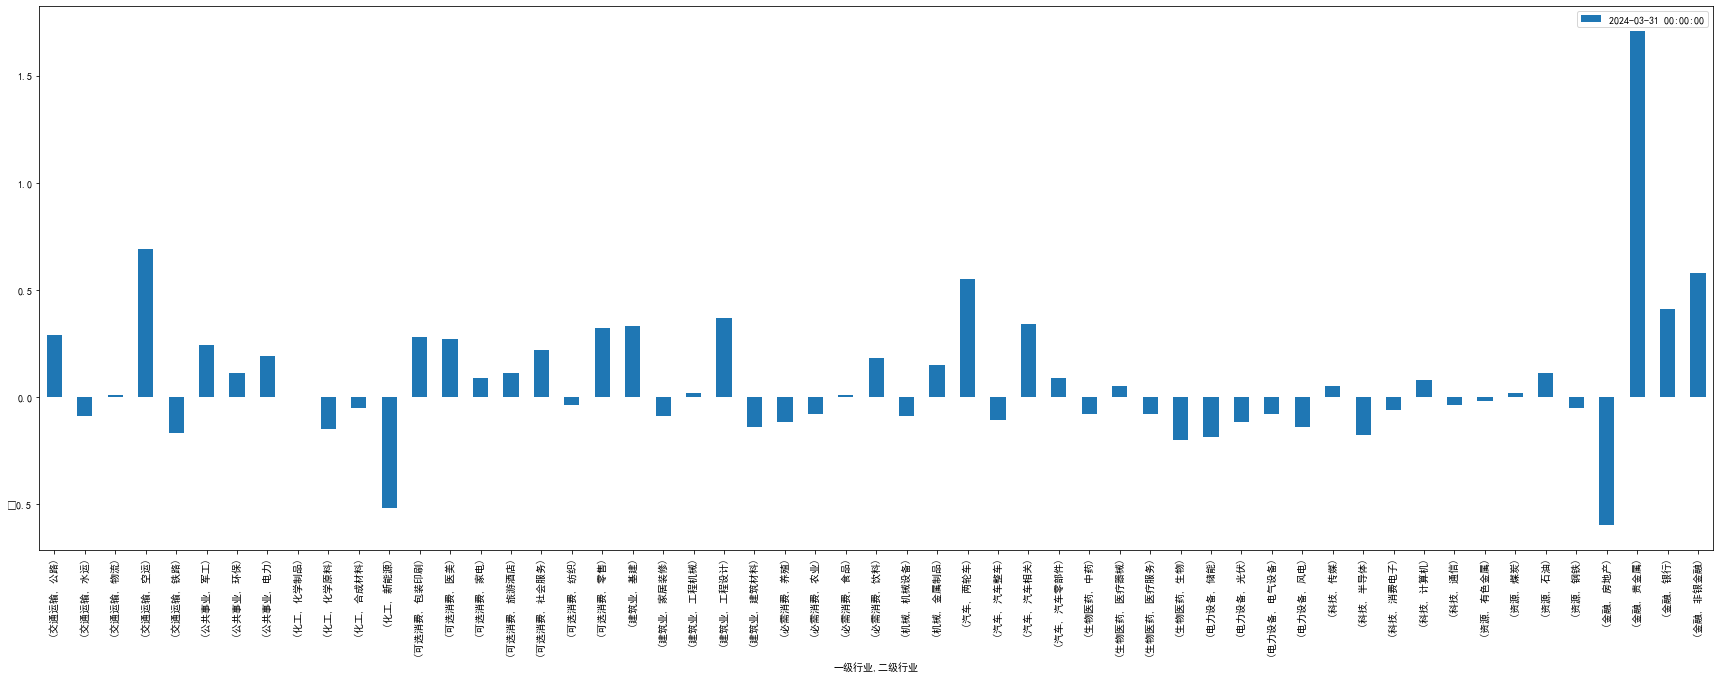

In [522]:
df = capex.groupby(['一级行业','二级行业']).sum().T/100000000
df.index = pd.to_datetime(df.index)
df = ((df - df.shift(4)) / df.shift(4)).dropna(how='all').round(2)
df.tail(1).T.plot.bar(figsize=(30,10))

In [33]:
help(pd.qcut)

Help on function qcut in module pandas.core.reshape.tile:

qcut(x, q, labels=None, retbins: 'bool' = False, precision: 'int' = 3, duplicates: 'str' = 'raise')
    Quantile-based discretization function.
    
    Discretize variable into equal-sized buckets based on rank or based
    on sample quantiles. For example 1000 values for 10 quantiles would
    produce a Categorical object indicating quantile membership for each data point.
    
    Parameters
    ----------
    x : 1d ndarray or Series
    q : int or list-like of float
        Number of quantiles. 10 for deciles, 4 for quartiles, etc. Alternately
        array of quantiles, e.g. [0, .25, .5, .75, 1.] for quartiles.
    labels : array or False, default None
        Used as labels for the resulting bins. Must be of the same length as
        the resulting bins. If False, return only integer indicators of the
        bins. If True, raises an error.
    retbins : bool, optional
        Whether to return the (bins, labels) or not.

C:\Users\Zhi\AppData\Local\Temp/ipykernel_33676/276073472.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df = total_inventory[total_inventory['二级行业'].isin(industry) ].groupby(['二级行业','三级行业']).sum().T/100000000


<AxesSubplot:>

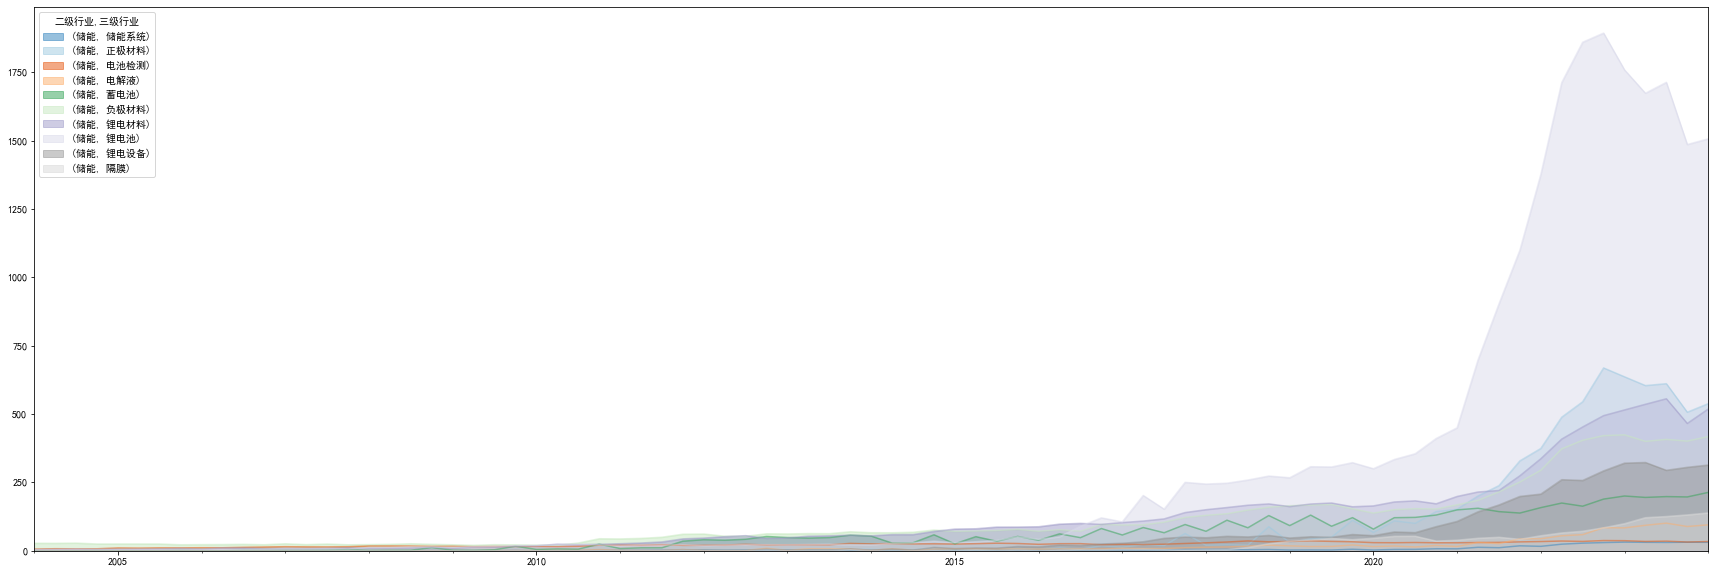

In [359]:
industry = ['储能']
# df = total_inventory[total_inventory['一级行业'].isin([industry])].groupby(['一级行业','二级行业']).sum().T   & (total_inventory['二级行业'] == '基建')
df = total_inventory[total_inventory['二级行业'].isin(industry) ].groupby(['二级行业','三级行业']).sum().T/100000000

df.index = pd.to_datetime(df.index)
df = df[(df.index > '2004-01-01')]
df.plot.area(stacked=False,xlabel = '',figsize=(30,10), colormap = 'tab20c')



C:\Users\Zhi\AppData\Local\Temp/ipykernel_33676/1000706001.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  inventory_df = inventory[inventory['二级行业'].isin([industry])].groupby(['一级行业','二级行业','项目']).sum().T
C:\Users\Zhi\AppData\Local\Temp/ipykernel_33676/1000706001.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  in_built_df  = in_built[in_built['二级行业'].isin([industry])].groupby(['一级行业','二级行业','项目']).sum().T


<AxesSubplot:>

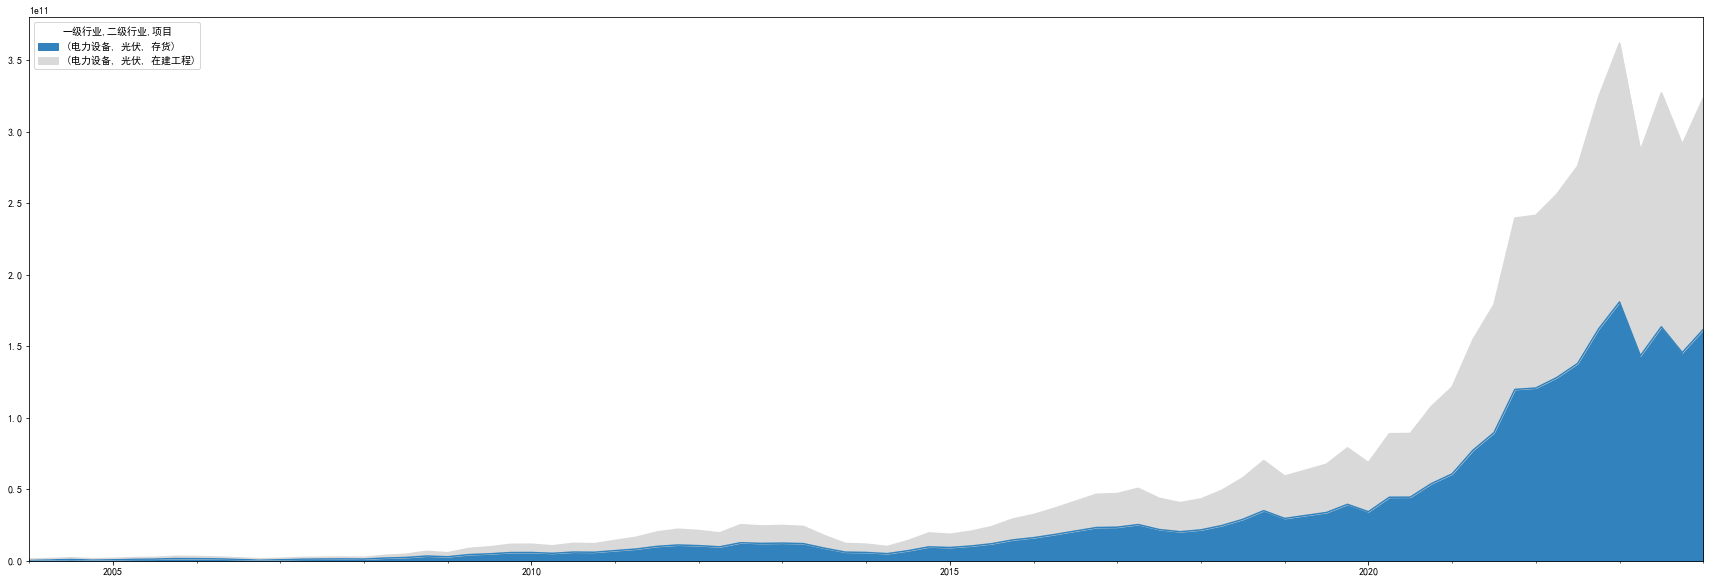

In [318]:
inventory = in_built.round(2)
inventory = a_stock.merge(inventory.reset_index(), on = '证券代码', how= 'left').drop(columns = ['证券代码','证券名称'])
in_built = in_built.round(2)
in_built = a_stock.merge(in_built.reset_index(), on = '证券代码', how= 'left').drop(columns = ['证券代码','证券名称'])
inventory['项目'] = '存货'
in_built['项目'] = '在建工程'

industry = '光伏'
inventory_df = inventory[inventory['二级行业'].isin([industry])].groupby(['一级行业','二级行业','项目']).sum().T
in_built_df  = in_built[in_built['二级行业'].isin([industry])].groupby(['一级行业','二级行业','项目']).sum().T
df = inventory_df.merge(in_built_df, left_on=inventory_df.index, right_on=in_built_df.index).set_index(keys=['key_0'])
df.index = pd.to_datetime(df.index)
df = df[(df.index > '2004-01-01')]
df.plot.area(stacked=True,xlabel = '',figsize=(30,10), colormap = 'tab20c')

In [126]:
import requests

url = 'https://datacenter-web.eastmoney.com/api/data/v1/get'
params = {
    'sortColumns': 'NOTICE_DATE,SECURITY_CODE',
    'sortTypes': '-1,-1',
    'pageSize': '6000',
    'pageNumber': '1',
    'reportName': 'RPT_DMSK_FN_BALANCE',
    'columns': 'ALL',
    'filter': '(SECURITY_TYPE_CODE in ("058001001","058001008"))(TRADE_MARKET_CODE!="069001017")' + "(REPORT_DATE='2020-03-31')" + "(EndDate='2024-04-30')"
}

r = requests.get(url, params=params, timeout=10)
data_json = r.json()

In [127]:
data_json

{'version': None,
 'result': None,
 'success': False,
 'message': 'EndDate列不存在',
 'code': 9501}

In [120]:
pd.set_option('display.max_columns', None)

pd.DataFrame(data_json['result']['data']).dropna(axis=1, how='all')

TypeError: 'NoneType' object is not subscriptable

In [128]:
from mootdx.affair import Affair

# 远程文件列表
files = Affair.files()



In [129]:
files

[{'filename': 'gpcw20240930.zip',
  'hash': '697aa0f931ea8bc16989a7caa0b4f492',
  'filesize': 165},
 {'filename': 'gpcw20240630.zip',
  'hash': '229ca99789110834b777da49482d6b0e',
  'filesize': 165},
 {'filename': 'gpcw20240331.zip',
  'hash': '0dee1d192f7dd492635e909b9303c1b5',
  'filesize': 4776683},
 {'filename': 'gpcw20231231.zip',
  'hash': '88d1e39b2fdba9cd9d3e25d77dfc0b71',
  'filesize': 5448875},
 {'filename': 'gpcw20230930.zip',
  'hash': '42f5eaabdf4ce7a9e438b6e37355992f',
  'filesize': 5072491},
 {'filename': 'gpcw20230630.zip',
  'hash': '9987df39d61c3461f54e7def2735b245',
  'filesize': 5388105},
 {'filename': 'gpcw20230331.zip',
  'hash': '9cbfd6ccb2d134ee13568d6b524d5313',
  'filesize': 4714437},
 {'filename': 'gpcw20221231.zip',
  'hash': 'c984f2395fe2eb968c1e9459fbdf83c4',
  'filesize': 5416650},
 {'filename': 'gpcw20220930.zip',
  'hash': '94dd6fc16bb295d4a0fdda1144251300',
  'filesize': 4779792},
 {'filename': 'gpcw20220630.zip',
  'hash': 'ae11cb837b13199d30384ea1ad3

In [134]:
# 下载单个
Affair.fetch(downdir='tmp', filename='gpcw20240331.zip')
result = Affair.parse(downdir='tmp', filename='gpcw20240331.zip')

4.78MB [00:11, 404kB/s] 


In [139]:
columns = [
    'report_date',
    '基本每股收益',
    '扣除非经常性损益每股收益',
    '每股未分配利润',
    '每股净资产',
    '每股资本公积金',
    '净资产收益率',
    '每股经营现金流量',

    '存货',
    '在建工程',
 
    '商誉',
 
    '资产总计',
    '负债合计',

    '流动比率(非金融类指标)',
    '速动比率(非金融类指标)',
    '现金比率(%)(非金融类指标)',

    '权益乘数(%)',

    '存货周转率(非金融类指标)',

    '存货周转天数(非金融类指标)',
 
    '营业收入增长率(%)',
    '净利润增长率(%)',
    '扣非净利润同比(%)',
  
    '营业利润率(非金融类指标)',
 
    '净资产收益率',
    
    '销售净利率(%)',
    '总资产报酬率',
    '净利润率(非金融类指标)',
    '销售毛利率(%)(非金融类指标)',
 
    
  
    '存货比率(非金融类指标)',
   
    
    '总股本',
  
    
    '第一大股东的持股数量',
    '十大流通股东持股数量合计(股)',
    '十大股东持股数量合计(股)',
    
    
    '机构总量（家）',
    '机构持股总量(股)',
    'QFII机构数',
    'QFII持股量',
    '券商机构数',
    '券商持股量',
    '保险机构数',
    '保险持股量',
    '基金机构数',
    '基金持股量',
    '社保机构数',
    '社保持股量',
    '私募机构数',
    '私募持股量',
    '财务公司机构数',
    '财务公司持股量',
    '年金机构数',
    '年金持股量',
    '十大流通股东中持有A股合计(股)',
    '第一大流通股东持股量(股)',
    '自由流通股(股)',
    '受限流通A股(股)',
    '一般风险准备(金融类)',
    '其他综合收益(利润表)',
    '综合收益总额(利润表)',
    '归属于母公司股东权益(资产负债表)',
    '银行机构数(家)(机构持股)',
    '银行持股量(股)(机构持股)',
    '一般法人机构数(家)(机构持股)',
    '一般法人持股量(股)(机构持股)',
    '近一年净利润(元)',
    '信托机构数(家)(机构持股)',
    '信托持股量(股)(机构持股)',
    '特殊法人机构数(家)(机构持股)',
    '特殊法人持股量(股)(机构持股)',
    
    '加权净资产收益率(每股指标)',

    '国家队持股数量（万股)',

    '基本每股收益（单季度）',

]
 


In [141]:
result[columns]

,report_date,基本每股收益,扣除非经常性损益每股收益,每股未分配利润,每股净资产,每股资本公积金,净资产收益率,净资产收益率,每股经营现金流量,存货,在建工程,商誉,资产总计,负债合计,流动比率(非金融类指标),速动比率(非金融类指标),现金比率(%)(非金融类指标),权益乘数(%),存货周转率(非金融类指标),存货周转天数(非金融类指标),营业收入增长率(%),净利润增长率(%),扣非净利润同比(%),营业利润率(非金融类指标),净资产收益率,净资产收益率,销售净利率(%),总资产报酬率,净利润率(非金融类指标),销售毛利率(%)(非金融类指标),存货比率(非金融类指标),总股本,第一大股东的持股数量,十大流通股东持股数量合计(股),十大股东持股数量合计(股),机构总量（家）,机构持股总量(股),QFII机构数,QFII持股量,券商机构数,券商持股量,保险机构数,保险持股量,基金机构数,基金持股量,社保机构数,社保持股量,私募机构数,私募持股量,财务公司机构数,财务公司持股量,年金机构数,年金持股量,十大流通股东中持有A股合计(股),第一大流通股东持股量(股),自由流通股(股),受限流通A股(股),一般风险准备(金融类),其他综合收益(利润表),综合收益总额(利润表),归属于母公司股东权益(资产负债表),银行机构数(家)(机构持股),银行持股量(股)(机构持股),一般法人机构数(家)(机构持股),一般法人持股量(股)(机构持股),近一年净利润(元),信托机构数(家)(机构持股),信托持股量(股)(机构持股),特殊法人机构数(家)(机构持股),特殊法人持股量(股)(机构持股),加权净资产收益率(每股指标),国家队持股数量（万股),基本每股收益（单季度）
code,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
000001,20240331,0.6600,0.660000,12.0595,21.420000,4.1617,3.075,3.075,-1.100,0.000000e+00,0.000000e+00,7.568000e+09,5.729398e+12,5.243822e+12,0.000,0.000,0.000000,11.80,0.000,0.0,-14.030000,2.260000,3.020000,47.860001,3.075,3.075,38.509998,0.264,38.514000,0.000000,0.000000,1.940592e+10,9.618541e+09,1.270886e+10,1.270886e+10,108.0,1.293820e+10,0.0,0.0,0.0,0.0,4.0,1.130401e+10,101.0,464342144.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.270886e+10,9.618541e+09,8.160428e+09,371248.0,6.804800e+10,3.450000e+08,1.527700e+10,4.855760e+11,0.0,0.0,1.0,6.252337e+07,4.678500e+10,0.0,0.0,1.0,429232704.0,3.15,42923.269531,0.6600
000002,20240331,-0.0305,-0.140362,7.8163,21.007401,2.1231,-0.144,-0.144,-0.790,6.720567e+11,2.526615e+09,5.537868e+09,1.463869e+12,1.064336e+12,1.385,0.547,10.353000,3.66,0.080,1125.0,-10.050000,-125.040001,-359.380005,1.100000,-0.144,-0.144,0.540000,-0.024,-0.588000,10.820000,60.487000,1.193071e+10,3.242811e+09,6.888030e+09,6.888030e+09,50.0,4.772160e+09,0.0,0.0,0.0,0.0,0.0,0.000000e+00,43.0,294185504.0,0.0,0.0,1.0,137271120.0,0.0,0.0,0.0,0.0,4.681680e+09,3.242811e+09,6.474125e+09,7260668.0,0.000000e+00,-5.092358e+07,2.803668e+08,2.506333e+11,0.0,0.0,3.0,3.803746e+09,1.795313e+10,0.0,0.0,2.0,318147584.0,-0.14,31814.759766,-0.0305
000006,20240331,-0.0197,-0.019920,2.1726,5.144900,0.3588,-0.383,-0.383,-0.236,1.712965e+10,7.426350e+06,0.000000e+00,2.576530e+10,1.835193e+10,1.753,0.364,28.177999,3.48,0.010,8591.0,-4.870000,-120.070000,-100.680000,-10.720000,-0.383,-0.383,-11.400000,-0.103,-10.525000,29.180000,79.250000,1.349995e+09,2.960314e+08,5.677226e+08,5.677226e+08,5.0,5.275306e+08,0.0,0.0,0.0,0.0,0.0,0.000000e+00,1.0,6398700.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.677226e+08,2.960314e+08,8.505992e+08,7650.0,0.000000e+00,0.000000e+00,-2.880840e+07,6.945543e+09,0.0,0.0,2.0,4.993882e+08,-9.174792e+08,0.0,0.0,1.0,16052200.0,-0.38,1605.219971,-0.0197
000007,20240331,0.0018,0.001674,-0.9219,0.364800,0.4532,0.507,0.507,0.077,3.573825e+07,0.000000e+00,0.000000e+00,3.969639e+08,2.585759e+08,2.185,1.906,147.231003,2.87,1.021,88.0,-12.610000,375.970001,-71.709999,2.070000,0.507,0.507,0.840000,0.161,1.480000,22.830000,12.756000,3.464480e+08,4.500013e+07,1.073046e+08,1.423395e+08,2.0,7.887339e+07,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.073046e+08,4.500013e+07,2.300747e+08,37500000.0,0.000000e+00,0.000000e+00,3.648482e+05,1.264008e+08,0.0,0.0,2.0,7.887339e+07,3.749978e+07,0.0,0.0,0.0,0.0,0.51,0.000000,0.0018
000008,20240331,-0.0179,-0.020025,-0.7036,1.290700,0.9644,-1.387,-1.387,-0.050,8.559517e+08,8.227626e+08,2.383081e+09,1.066344e+10,7.059682e+09,0.750,0.618,8.077000,2.96,0.126,712.0,-58.200001,-47.560001,-59.459999,-27.700001,-1.387,-1.387,-29.750000,-0.456,-26.962000,42.020000,17.556999,2.716378e+09,7.124184e+08,1.240216e+09,1.270441e+09,4.0,1.124621e+09,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.240216e+09,7.124184e+08,1.613531e+09,40428424.0,0.000000e+00,1.378204e+05,-5.350668e+07,3.506032e+09,0.0,0.0,3.0,1.086172e+09,-8.473612e+08,0.0,0.0,0.0,0.0,-1.54,0.000000,-0.0179
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...

In [14]:
total_df[total_df['industryName'] == '食品饮料']


,title,publishTime,pageCount,reportSubType,orgName,author,newFortureList,industryName,ratingContent,id
0,食品饮料行业2023年报、2024年一季报总结：白酒兑现预期，大众盈利修复,2024-05-06,31,行业定期,华创证券,"欧阳予,沈昊,范子盼,彭俊霖,田晨曦,董广阳","[1, 1, 1, 1, 0, 1]",食品饮料,推荐,5616327
42,白酒行业周报（20240415-20240421）：淡季控货筑基，酒企务实去库,2024-04-22,7,行业定期,华创证券,"沈昊,欧阳予,田晨曦,刘旭德,董广阳","[1, 1, 0, 0, 1]",食品饮料,推荐,5595521
7,中低速时代的定价范式三：食品饮料高分红企业全景梳理,2024-04-21,17,行业深度,华创证券,"欧阳予,董广阳","[1, 1]",食品饮料,推荐,5593301
12,供应链提效浪潮：零食行业三轮变迁与未来演进深度研究,2024-04-18,34,行业深度,华创证券,"欧阳予,范子盼,董广阳","[1, 1, 1]",食品饮料,推荐,5590771
26,白酒行业周报（20240408-20240414）：透过飞天批价扰动，浅析巽风的三重增量,2024-04-15,7,行业定期,华创证券,"沈昊,欧阳予,田晨曦,刘旭德,董广阳","[1, 1, 0, 0, 1]",食品饮料,推荐,5585500
24,食品饮料行业2024年一季报前瞻：白酒头部无虞，大众分化延续,2024-04-07,20,行业定期,华创证券,"欧阳予,沈昊,范子盼,彭俊霖,田晨曦,董广阳","[1, 1, 1, 1, 0, 1]",食品饮料,推荐,5574084
33,食品饮料行业跟踪报告：预制菜新规落地：正本清源，龙头受益,2024-04-02,9,行业动态,华创证券,"欧阳予,彭俊霖,董广阳","[1, 1, 1]",食品饮料,推荐,5570212
30,白酒行业周报（20240318-20240324）：糖酒会酒企经销商大会反馈：务实理性，释放信心,2024-03-24,6,行业定期,华创证券,"沈昊,欧阳予,田晨曦,刘旭德,董广阳","[1, 1, 0, 0, 1]",食品饮料,推荐,5555464
43,白酒行业春糖反馈报告：略超预期，看点在“价”,2024-03-18,9,行业定期,华创证券,"沈昊,欧阳予,田晨曦,刘旭德,董广阳","[1, 1, 0, 0, 1]",食品饮料,推荐,5547578
37,白酒行业周报（20240304-20240310）：寻找淡季中的“小亮点”,2024-03-11,8,行业定期,华创证券,"沈昊,欧阳予,田晨曦,刘旭德,董广阳","[1, 1, 0, 0, 1]",食品饮料,推荐,5539251


In [1]:
from selenium import webdriver
driver = webdriver.Chrome()

In [23]:
from selenium import webdriver
driver = webdriver.Chrome()
driver.get("https://robo.datayes.com/v2/fastreport/industry")
cookie_list = [item["name"] + "=" + item["value"] for item in driver.get_cookies()]
cookies = {'Cookie':';'.join(item for item in cookie_list)}
driver.quit()

headers = {
'Accept': 'application/json, text/plain, */*',
'Accept-Encoding': 'gzip, deflate, br, zstd',
'Accept-Language': 'zh-cn',
'Connection': 'keep-alive',
'Host': 'gw.datayes.com',
'Origin': 'https://robo.datayes.com',
'Referer': 'https://robo.datayes.com/',
'Sec-Fetch-Dest': 'empty',
'Sec-Fetch-Mode': 'cors',
'Sec-Fetch-Site': 'same-site',
'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36',
'sec-ch-ua': '"Chromium";v="124", "Google Chrome";v="124", "Not-A.Brand";v="99"',
'sec-ch-ua-mobile': '?0',
'sec-ch-ua-platform': '"Windows"'
}

In [24]:
import requests
import pandas as pd
from tqdm import tqdm

total_df = pd.DataFrame()
for page in tqdm(range(1,2)):
    url = f'https://gw.datayes.com/rrp_adventure/web/search'
    payload ={
        'pageNow': str(page),
        'authorId': '',
        'isOptional': '国金证券',
        'reportType': 'INDUSTRY',
        'secCodeList': '',
        'reportSubType':'',
        'industry': '',
        'ratingType': '',
        'pubTimeStart': '20240513',
        'pubTimeEnd': '20240521',
        'type': 'EXTERNAL_REPORT',
        'pageSize': '40',
        'sortOrder': 'desc',
        'query':'' ,
        'minPageCount':'' ,
        'maxPageCount':'' ,
    }


    r = requests.get(url, params=payload, headers = headers, cookies = cookies)
    df = pd.DataFrame(pd.DataFrame(r.json()['data']['list'])['data'].tolist())[['title','publishTime','pageCount','reportSubType','orgName','author','newFortureList','industryName','ratingContent','id']]
    total_df = pd.concat([total_df,df])

  0%|                                                                                                                                                                                | 0/1 [00:00<?, ?it/s]


KeyError: 'data'

In [285]:
import requests
import pandas as pd
from tqdm import tqdm

total_df = pd.DataFrame()
for page in tqdm(range(1,7)):
    url = 'https://reportapi.eastmoney.com/report/list'
    payload ={
        'industryCode': '*',
        'pageSize': '100',
        'industry': '*',
        'rating': '*',
        'ratingChange': '*',
        'beginTime': '2024-05-19',
        'endTime': '2024-05-22',
        'pageNo': str(page),
        'qType': '1'
    }

    r = requests.get(url, params = payload)
    df = pd.DataFrame(r.json()['data'])[['title','orgSName','publishDate','infoCode','industryCode','industryName','emRatingValue','researcher']]
    df['publishDate'] = pd.to_datetime(df['publishDate']).dt.date.astype(str)
    total_df = pd.concat([total_df,df])

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:01<00:00,  4.34it/s]


In [284]:
r.json()['TotalPage']

6

In [286]:

mappings = {
    '能源': [['国金证券'], ['石油行业','煤炭行业','采掘行业','燃气']],
    '有色金属': [['国金证券','华福证券'], ['有色金属','小金属','能源金属','贵金属']],
    '钢铁': [['华福证券'], ['钢铁行业','煤炭行业']],
    '化工': [['国金证券','国海证券'], ['化学制品','化纤行业','化学原料', '化肥行业', '塑料制品','橡胶制品', '非金属材料']],  
    
    '电力': [['国金证券'],['公用事业','电力行业','环保行业']], 
    '电力设备': [['国金证券','华福证券'], ['光伏设备','电池','风电设备','电网设备', '电源设备']], 
    
    '房地产': [['国金证券'],['房地产开发','房地产服务']], 
    '建材': [['国投证券','国信证券'], ['水泥建材','装修建材','玻璃玻纤']], 
    '建筑': [['国投证券'], ['工程建设','装修装饰']],  
    
    '金融': [['国金证券','华福证券'], ['银行', '证券','多元金融','保险']],
    '汽车': [['国金证券','华福证券'], ['汽车服务','汽车整车', '汽车零部件','交运设备']],
    '机械': [['国金证券'], ['专用设备', '通用设备','仪器仪表','工程机械']],
    '家电': [['国金证券','华福证券'], ['家电行业']],
    '电子': [['国金证券','华福证券'],['半导体', '消费电子','电子元件', '光学光电子','电子化学品']],
    
    '科技': [['国金证券','华福证券'], ['计算机设备',  '游戏', '通信设备', '通信服务', '互联网服务','软件开发','文化传媒']],
    '医药': [['国金证券','华福证券'], ['生物制品','医疗器械', '化学制药','医药商业','医疗服务','中药']],
    '食品饮料': [['国金证券','华福证券'], ['酿酒行业','食品饮料']],
    '农牧饲渔': [['国金证券'], ['农牧饲渔']],
    '轻工制造': [['华安证券','上海证券'], ['纺织服装', '家用轻工','造纸印刷', '包装材料']],
    '商贸零售': [['上海证券'], [ '商业百货', '美容护理', '珠宝首饰']],
    '社会服务': [['万联证券'], ['旅游酒店','教育','专业服务']], 
    '交通运输': [['国金证券','华福证券'], ['航运港口','航空机场', '物流行业','铁路公路']],
    
    '军工': [['中航证券'],['航天航空', '船舶制造']],
    
}

In [309]:
total_df.loc[total_df['title'].str.contains('能源周'), 'industryName'] = '石油行业'

df = pd.DataFrame(mappings).T

def format_title(x):
    try:
        if len(x.split('：')) > 1:
            x = ':'.join(x.split('：')[1:])
        else:
            x = x.split('：')[-1]
    except:
        pass   
    return x


df['title'] = '' 
df['infoCode'] = ''
for i, row in df.iterrows():
    tmp = total_df[total_df['orgSName'].isin(row[0]) & total_df['industryName'].isin(row[1])]
    tmp['title'] = tmp['title'].apply(format_title)
    df.loc[i, 'title'] = (tmp['publishDate'] + ' || ' + tmp['title']).to_list()
    df.loc[i, 'infoCode'] = tmp['infoCode'].to_list()

C:\Users\Zhi\AppData\Local\Temp/ipykernel_38148/3164734447.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp['title'] = tmp['title'].apply(format_title)


In [310]:
from requests_html import HTMLSession

def fetch_highlight(infocode_list):
    highlight_list = []
    for infocode in infocode_list:
        url = f'https://data.eastmoney.com/report/zw_industry.jshtml?infocode={infocode}'
        session = HTMLSession()  
        r = session.get(url)  
        highlight = r.html.find('div.ctx-content')[0].text.replace('\n','').split('风险提示')[0]
        highlight_list.append(highlight)
        # pdf_link = list(r.html.find('a.pdf-link')[0].links)[0]
    return highlight_list
#使用tqdm进度条
tqdm.pandas() 
df['highlight'] = df['infoCode'].progress_map(fetch_highlight)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 23/23 [00:12<00:00,  1.84it/s]


In [308]:
# display
from IPython.display import display, HTML
def to_str(x):
    try:
        x = '<br>'.join(x)
    except:
        pass
    return x



df['title'] = df['title'].apply(to_str)
df = df[['title','highlight']].fillna('').style.set_properties(**{'text-align': 'left'})
display(HTML(df.to_html(escape=False, justify='left')))

In [126]:
def format_title(x):
    try:
        if len(x.split('：')) > 1:
            x = ':'.join(x.split('：')[1:])
        else:
            x = x.split('：')[-1]
    except:
        pass   
    return x

total_df['publishTime'] = pd.to_datetime(total_df['publishTime']).dt.date.astype(str)
regular =  pd.DataFrame(total_df[(total_df['reportSubType']=='行业定期') | (total_df['title'].str.contains('周报'))].sort_values(['industryName','publishTime'],ascending = False).reset_index(drop = True))[['industryName','title','publishTime']]
regular['title'] = regular['title'].apply(format_title)
regular['regular'] = regular['publishTime'] + ' || ' + regular['title']
regular = pd.DataFrame(regular.groupby('industryName')['regular'].apply(list))

depth = pd.DataFrame(pd.DataFrame(total_df[(total_df['reportSubType']!='行业定期') & (total_df['title'].str.contains('周报') == False)].sort_values(['industryName','publishTime'],ascending = False).reset_index(drop = True))[['industryName','title','publishTime']])
depth['depth'] =depth['publishTime'] + ' || ' + depth['title']
depth = pd.DataFrame(depth.groupby('industryName')['depth'].apply(list))

#.groupby('industryName')['title','publishTime'].apply(list)).rename(columns={"title": "depth"})

In [129]:
def fetch_highlight(id):
    url = f'https://gw.datayes.com/rrp_adventure/researchQuickReport/getAbstractByReportId?reportId={id}'
    r = requests.get(url,headers = headers, cookies = cookies)
    highlight = r.json()['data'].replace('<p>','').replace('</p>','').replace('&amp;','&')
    return highlight

total_df['highlight'] = total_df['id'].apply(fetch_highlight)

In [317]:
qwen_df = df[['title','highlight']].rename(columns = {'title':'标题','highlight':'摘要'})

In [334]:
qwen_df['千问读研报'] = qwen_df['摘要'].apply(make_query).progress_map(ask_qwen)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 23/23 [07:54<00:00, 20.64s/it]


In [353]:
display(HTML(qwen_df['千问读研报'].reset_index().style.set_properties(**{'text-align': 'left'}).to_html(escape=False, justify='left')))

,index,千问读研报
0,能源,行业分析：券商研报摘要指出，原油行业当前的主要因素集中在供应端相对稳定，OPEC+维持减产，而需求端则受到美国成品油需求不足和中国消费数据的影响。油价在短期内受到地缘政治风险和中国经济数据的提振，布油价格在82-85美元/桶区间内波动，可能在需求数据进一步好转时有所上升。天然气方面，美国供应稳定，需求有所改善，欧洲库存增速放缓，预测气价将上涨。推荐标的及理由：1. 原油相关股票/ETF： - 推荐标的A：石油公司X - 理由：受益于OPEC+的减产策略和需求复苏的预期，公司具有稳定的产量和良好的成本控制能力。若油价上行，公司利润有望提升。 2. 天然气公司Y： - 理由：美国天然气市场供需改善，公司有潜力受益于价格上涨。随着秋季需求恢复，公司业绩可期。3. 能源基础设施Z： - 理由：作为油气输送和存储的关键环节，基础设施的需求与能源价格变动紧密相关，需求稳定增长时，公司价值有望显现。4. 煤炭相关股票/ETF： - 推荐标的B：煤炭开采公司W - 理由：虽然国内煤炭需求有所下滑，但夏季高温可能导致用电需求增加，且煤炭作为传统能源，需求仍有保障。关注政策调整对行业的影响。5. 电力公司U： - 理由：电力公司对煤炭依赖较大，但夏季用电高峰和气温上升预期将提振需求。同时，清洁能源转型也可能带来新的投资机会。投资建议：在当前环境下，投资者应关注原油、天然气和煤炭行业的供需动态，选择基本面稳健、抗风险能力强的公司进行投资。同时，电力公司也值得关注其夏季用电需求的季节性变化。但请务必结合个人投资目标、风险承受能力和市场环境进行具体的投资决策。
1,有色金属,总结行业现状：1. 贵金属：受美核心CPI降温、美元美债走弱影响，金价有上涨预期。美元美债的下跌推动了沪金价格走高。尽管4月通胀放缓，但鉴于市场对降息的预期增强，黄金作为避险资产受到青睐。2. 有色及稀土：有色指数本周上涨，但个股表现分化。稀土价格回调，进口量下滑，政策支持有望推动磁材相关领域受益于制造升级和更新改造。中长期看，稀土价格中枢可能上行，北方稀土（轻稀土龙头）值得关注。3. 锑、钼、锡、钨：锑和钼价格因供需错配和产能周期影响上涨，预计价格创新高。锡和钨价格因供应紧张和需求复苏而走强，建议关注湖南黄金和中钨高新。4. 铜、铝：铜价上涨受全球库存低位、需求旺季和政策支持影响。铝价受中美贸易关系及房地产政策提振，电解铝供需缺口有望推动价格上涨。中国铝业、中国宏桥、天山铝业和紫金矿业等公司值得关注。推荐标的及理由：1. 山东黄金（贵金属）：吨资源量市值较低，Q2黄金股有望迎来主升浪，受益于美联储可能的降息政策。2. 金钼股份（钼矿）：钼产业链景气持续，价格上行，但新增供应有限，库存去化，紫金矿业产量指引下调反而提供买入机会。3. 湖南黄金（锑）：锑供需格局向好，价格有望创新高，受益于产能周期和环保限产。4. 中国铝业、中国宏桥、天山铝业（铝）：铝价受地产政策提振，电解铝供需缺口扩大，关注上游资源丰富的公司。5. 紫金矿业（铜、钼、钨）：公司钼产量指引调整，但沙坪沟钼矿前景积极，整体钼供需偏紧，钼价中枢上行，值得长期关注。请注意，投资决策应结合最新的市场数据、宏观经济状况以及公司的基本面信息，以上分析仅为参考，具体投资需谨慎。
2,钢铁,行业分析：1. 钢铁行业：当前钢材消费呈现“淡季不淡”的趋势，政策利好的释放带动下游需求恢复，尤其是房地产市场的支持措施有助于提振市场信心。供给端，钢厂复产节奏加快，尽管原料端铁矿石到港量高位，但库存压力减小，铁水产量稳步增长。产业链数据显示，库存下降，供需关系改善，对钢价形成支撑。普钢板块推荐南钢股份、华菱钢铁、新兴铸管，因其估值低、股息稳定；特钢板块推荐中信特钢、常宝股份、甬金股份，兼顾盈利弹性与股息。2. 动力煤和炼焦煤：动力煤方面，随着夏季用电高峰的到来，需求预期增加，加上政策利好，市场情绪转强。然而，由于电厂库存高位，短期内需求拉动有限。炼焦煤方面，焦煤和焦炭库存低位，供给受限于安全检查，炼焦煤供需可能进一步收紧，叠加下游钢铁消费高位，利好相关公司。推荐动力煤板块的中国神华、陕西煤业、中煤能源（估值修复机会），以及炼焦煤板块的潞安环能、山西焦煤、冀中能源（业绩稳健、分红高）。总结：整体来看，钢铁和煤炭行业均呈现出供需改善、政策驱动的态势，尤其是煤炭市场在旺季来临前需求预期提升。投资者可关注具有稳定盈利和较高分红的龙头公司，以及受益于政策支持和供需紧平衡的细分板块。但同时要注意市场情绪的变化和钢厂生产节奏，以把握投资机会。
3,化工,行业分析：1. 新材料行业：新材料作为化工行业的重要发展方向，随着政策扶持和技术创新，国内企业将迎来加速发展阶段。电子信息、航空航天、新能源和生物技术等领域的应用需求驱动新材料公司的发展，如半导体材料、PI薄膜、光伏材料、生物刺激素等。2. 化工行业景气度：国海化工景气指数维持在高位，化工行业整体景气度见底回升，供给端欧洲产能有退出迹象，国内落后产能有望出清，新增产能趋于饱和，需求端内外需稳定，化工巨头盈利改善，显示出行业下行风险减轻。3. 投资机会： - 低成本扩张标的：万华化学、玲珑轮胎、赛轮轮胎、森麒麟等。 - 景气度提升行业：轮胎设备、制冷剂、涤纶长丝、磷矿石、复合肥、萤石、炼化、粘胶短纤、不溶性硫磺、草铵膦、新材料行业（如PI膜、电子化学品、氟冷液、吸附材料、合成生物学等）。 - 高股息央国企：中国石油、中国海油、中国石化、中国化学等。推荐标的及理由：1. 万华化学：作为MDI龙头，公司新项目稳步推进，且受益于行业景气度提升和产能扩张，预计盈利能力将持续增强。2. 龙佰集团：在钢铁和新材料领域有竞争优势，特别是钛白粉业务，随着地产政策的调整，钛白粉需求可能复苏。3. 宝丰能源：作为煤化工企业，有望受益于供给端收缩和环保政策，同时新能源业务发展也有潜力。这些公司不仅在行业内具有领先地位，且受益于行业发展趋势和政策支持，具有较高的增长性和稳定性，值得重点关注。然而，投资需结合具体财务数据、市场环境和风险因素进行深入分析。
4,电力,行业现状分析：当前券商行业研报显示，公用事业板块本周表现一般，环保板块略有上涨，而煤炭板块则有所下跌，碳中和板块小幅上涨。研报特别提到了中国与美国在人均用电量上的对比，中国作为全球制造业大国，电力需求依然强劲，尤其是第二产业和第三产业的增长以及居民用电的提升，使得人均用电量有较大的增长空间。此外，政府对节能减排和清洁能源的推动，如广东省和苏州市的政策，以及生态环境部的排污许可制方案，预示着电力行业将朝着清洁、高效和低碳的方向发展。推荐标的及理由：1. 火电板块：推荐浙能电力和皖能电力，因为它们的发电资产集中在电力供需紧张且竞争格局良好的地区，这样的市场环境有利于提高发电效率和盈利能力。2. 水电板块：长江电力是龙头，受益于水电资源丰富和稳定的发电特性，在清洁能源转型中具有竞争优势。3. 核电板块：中国核电作为行业领导者，受益于国家对核电发展的支持和技术进步，具有长期投资价值。4. 新能源板块：南网能源作为综合能源运营商，随着能源结构转型和国家对可再生能源的支持，其业务有望进一步拓展，具有潜力。总体来说，投资策略应倾向于那些在清洁能源、电力供需平衡以及节能减排政策导向下的公司，这些公司将从行业发展趋势和政策扶持中获益。
5,电力设备,行业总结：1. 工控行业：当前处于去库存的后周期阶段，但Q2有望随着库存调整和市场需求改善，进入库存周期切换，预计全年增速微增0-5%。新能源行业如光伏和锂电需求下滑，传统制造如纺织、塑料复苏强劲。头部厂商受益份额提升，订单增速可能高于行业平均水平。2. 数字电网：随着电网数字化进程加快，数字配网投资增长确定性强，尤其在配电网建设和储能等领域。数字化技术将提升运维效率，降低损耗。国内电网巨头加大了数字化转型力度，投资规模将持续扩大。3. 电动交通：锂电关税政策利空出尽，低空领域政策支持增强。光伏板块关注东南亚双反调查进展，风电板块海风项目加速，储能市场容量交易引入新机制。4. 光伏与储能：美国关税政策影响减弱，行业底部夯实，优势企业有望受益于贸易壁垒。电网领域招标大幅增长，智能电表和变压器出口有望受益。5. 氢能：氢能应用领域加速拓展，交通、政策支持相继出台，有望带动消纳空间扩大。推荐标的及理由：- 工控：汇川技术、伟创电气、麦格米特、雷赛智能：头部企业受益库存周期切换和份额提升，业绩有望复苏。- 数字电网：国电南瑞、国网信通、威胜信息（软件平台）、申昊科技、亿嘉和（传感硬件）：数字化转型带来投资机会。- 电动交通：三星医疗（配电业务）、明阳电气（变压器出海）：受益于政策环境和行业需求。- 风电：关注海风产业链企业，出口业务复苏明显。- 氢能：关注氢能基础设施建设相关的公司，如政策推动下的加氢站建设。具体投资建议与估值，请参考报告正文中的详细分析和子行业观点。
6,房地产,根据两篇券商行业研报的摘要，我们可以总结出当前房地产行业的发展现状如下：1. 行业整体呈现复苏迹象：A股和港股地产板块以及物业板块上周均有上涨，特别是物业板块表现突出。新房和二手房销售虽有波动，但环比有所上升，显示出政策效应正在逐步显现。2. 政策支持力度加大：中央密集出台多项政策措施，包括降低首付比例、取消利率下限、下调公积金贷款利率，旨在刺激需求、保交付和去库存。这些政策有助于降低购房门槛，提振市场信心。3. 保交付与去库存并重：政府通过多种方式确保已售项目按时交付，并通过国企收储和再贷款等方式处理过剩库存，以稳定市场供应。4. 国资房企和中介平台受推荐：由于政

In [342]:
def to_str(x):
    try:
        x = '<br>'.join(x)
    except:
        pass
    return x



qwen_df['标题'] = qwen_df['标题'].apply(to_str)
qwen_df['千问读研报'] = qwen_df['千问读研报'].str.replace
display(HTML(qwen_df[['标题','千问读研报']].to_html(escape=False, justify='left')))

,标题,千问读研报
能源,[2024-05-20 || 油价若要继续上行，还需更多需求利好支撑],行业分析：\n\n券商研报摘要指出，原油行业当前的主要因素集中在供应端相对稳定，OPEC+维持减产，而需求端则受到美国成品油需求不足和中国消费数据的影响。油价在短期内受到地缘政治风险和中国经济数据的提振，布油价格在82-85美元/桶区间内波动，可能在需求数据进一步好转时有所上升。天然气方面，美国供应稳定，需求有所改善，欧洲库存增速放缓，预测气价将上涨。\n\n推荐标的及理由：\n\n1. 原油相关股票/ETF：\n - 推荐标的A：石油公司X\n - 理由：受益于OPEC+的减产策略和需求复苏的预期，公司具有稳定的产量和良好的成本控制能力。若油价上行，公司利润有望提升。\n \n2. 天然气公司Y：\n - 理由：美国天然气市场供需改善，公司有潜力受益于价格上涨。随着秋季需求恢复，公司业绩可期。\n\n3. 能源基础设施Z：\n - 理由：作为油气输送和存储的关键环节，基础设施的需求与能源价格变动紧密相关，需求稳定增长时，公司价值有望显现。\n\n4. 煤炭相关股票/ETF：\n - 推荐标的B：煤炭开采公司W\n - 理由：虽然国内煤炭需求有所下滑，但夏季高温可能导致用电需求增加，且煤炭作为传统能源，需求仍有保障。关注政策调整对行业的影响。\n\n5. 电力公司U：\n - 理由：电力公司对煤炭依赖较大，但夏季用电高峰和气温上升预期将提振需求。同时，清洁能源转型也可能带来新的投资机会。\n\n投资建议：在当前环境下，投资者应关注原油、天然气和煤炭行业的供需动态，选择基本面稳健、抗风险能力强的公司进行投资。同时，电力公司也值得关注其夏季用电需求的季节性变化。但请务必结合个人投资目标、风险承受能力和市场环境进行具体的投资决策。
有色金属,"[2024-05-20 || 降息预期加强及宏观利好政策提振有色市场，继续推荐金铜铝锑, 2024-05-20 || 海内外锑价创历史新高，硬缺口下继续看涨, 2024-05-20 || 地产支持政策有望扭转电解铝板块预期差, 2024-05-19 || 钼:中长期增量或不及预期，供需格局有望改善]",总结行业现状：\n1. 贵金属：受美核心CPI降温、美元美债走弱影响，金价有上涨预期。美元美债的下跌推动了沪金价格走高。尽管4月通胀放缓，但鉴于市场对降息的预期增强，黄金作为避险资产受到青睐。\n2. 有色及稀土：有色指数本周上涨，但个股表现分化。稀土价格回调，进口量下滑，政策支持有望推动磁材相关领域受益于制造升级和更新改造。中长期看，稀土价格中枢可能上行，北方稀土（轻稀土龙头）值得关注。\n3. 锑、钼、锡、钨：锑和钼价格因供需错配和产能周期影响上涨，预计价格创新高。锡和钨价格因供应紧张和需求复苏而走强，建议关注湖南黄金和中钨高新。\n4. 铜、铝：铜价上涨受全球库存低位、需求旺季和政策支持影响。铝价受中美贸易关系及房地产政策提振，电解铝供需缺口有望推动价格上涨。中国铝业、中国宏桥、天山铝业和紫金矿业等公司值得关注。\n\n推荐标的及理由：\n1. 山东黄金（贵金属）：吨资源量市值较低，Q2黄金股有望迎来主升浪，受益于美联储可能的降息政策。\n2. 金钼股份（钼矿）：钼产业链景气持续，价格上行，但新增供应有限，库存去化，紫金矿业产量指引下调反而提供买入机会。\n3. 湖南黄金（锑）：锑供需格局向好，价格有望创新高，受益于产能周期和环保限产。\n4. 中国铝业、中国宏桥、天山铝业（铝）：铝价受地产政策提振，电解铝供需缺口扩大，关注上游资源丰富的公司。\n5. 紫金矿业（铜、钼、钨）：公司钼产量指引调整，但沙坪沟钼矿前景积极，整体钼供需偏紧，钼价中枢上行，值得长期关注。\n\n请注意，投资决策应结合最新的市场数据、宏观经济状况以及公司的基本面信息，以上分析仅为参考，具体投资需谨慎。
钢铁,"[2024-05-20 || 利好政策加码叠加消费继续好转，市场信心提振, 2024-05-20 || 矿山开工有所恢复，“迎峰度夏”有望提前]",行业分析：\n\n1. 钢铁行业：当前钢材消费呈现“淡季不淡”的趋势，政策利好的释放带动下游需求恢复，尤其是房地产市场的支持措施有助于提振市场信心。供给端，钢厂复产节奏加快，尽管原料端铁矿石到港量高位，但库存压力减小，铁水产量稳步增长。产业链数据显示，库存下降，供需关系改善，对钢价形成支撑。普钢板块推荐南钢股份、华菱钢铁、新兴铸管，因其估值低、股息稳定；特钢板块推荐中信特钢、常宝股份、甬金股份，兼顾盈利弹性与股息。\n\n2. 动力煤和炼焦煤：动力煤方面，随着夏季用电高峰的到来，需求预期增加，加上政策利好，市场情绪转强。然而，由于电厂库存高位，短期内需求拉动有限。炼焦煤方面，焦煤和焦炭库存低位，供给受限于安全检查，炼焦煤供需可能进一步收紧，叠加下游钢铁消费高位，利好相关公司。推荐动力煤板块的中国神华、陕西煤业、中煤能源（估值修复机会），以及炼焦煤板块的潞安环能、山西焦煤、冀中能源（业绩稳健、分红高）。\n\n总结：整体来看，钢铁和煤炭行业均呈现出供需改善、政策驱动的态势，尤其是煤炭市场在旺季来临前需求预期提升。投资者可关注具有稳定盈利和较高分红的龙头公司，以及受益于政策支持和供需紧平衡的细分板块。但同时要注意市场情绪的变化和钢厂生产节奏，以把握投资机会。
化工,"[2024-05-21 || 美国加征自华进口电动汽车及半导体关税，2024年新能源汽车下乡活动开展, 2024-05-20 || 工业一铵、PVC、维生素价格上涨，关注地产链化工品投资机会, 2024-05-20 || 地产发力，周期行情有望继续]",行业分析：\n\n1. 新材料行业：新材料作为化工行业的重要发展方向，随着政策扶持和技术创新，国内企业将迎来加速发展阶段。电子信息、航空航天、新能源和生物技术等领域的应用需求驱动新材料公司的发展，如半导体材料、PI薄膜、光伏材料、生物刺激素等。\n\n2. 化工行业景气度：国海化工景气指数维持在高位，化工行业整体景气度见底回升，供给端欧洲产能有退出迹象，国内落后产能有望出清，新增产能趋于饱和，需求端内外需稳定，化工巨头盈利改善，显示出行业下行风险减轻。\n\n3. 投资机会：\n - 低成本扩张标的：万华化学、玲珑轮胎、赛轮轮胎、森麒麟等。\n - 景气度提升行业：轮胎设备、制冷剂、涤纶长丝、磷矿石、复合肥、萤石、炼化、粘胶短纤、不溶性硫磺、草铵膦、新材料行业（如PI膜、电子化学品、氟冷液、吸附材料、合成生物学等）。\n - 高股息央国企：中国石油、中国海油、中国石化、中国化学等。\n\n推荐标的及理由：\n\n1. 万华化学：作为MDI龙头，公司新项目稳步推进，且受益于行业景气度提升和产能扩张，预计盈利能力将持续增强。\n2. 龙佰集团：在钢铁和新材料领域有竞争优势，特别是钛白粉业务，随着地产政策的调整，钛白粉需求可能复苏。\n3. 宝丰能源：作为煤化工企业，有望受益于供给端收缩和环保政策，同时新能源业务发展也有潜力。\n\n这些公司不仅在行业内具有领先地位，且受益于行业发展趋势和政策支持，具有较高的增长性和稳定性，值得重点关注。然而，投资需结合具体财务数据、市场环境和风险因素进行深入分析。
电力,[2024-05-20 || 中美人均用电量及变动规律有何不同？],行业现状分析：\n\n当前券商行业研报显示，公用事业板块本周表现一般，环保板块略有上涨，而煤炭板块则有所下跌，碳中和板块小幅上涨。研报特别提到了中国与美国在人均用电量上的对比，中国作为全球制造业大国，电力需求依然强劲，尤其是第二产业和第三产业的增长以及居民用电的提升，使得人均用电量有较大的增长空间。此外，政府对节能减排和清洁能源的推动，如广东省和苏州市的政策，以及生态环境部的排污许可制方案，预示着电力行业将朝着清洁、高效和低碳的方向发展。\n\n推荐标的及理由：\n\n1. 火电板块：推荐浙能电力和皖能电力，因为它们的发电资产集中在电力供需紧张且竞争格局良好的地区，这样的市场环境有利于提高发电效率和盈利能力。\n2. 水电板块：长江电力是龙头，受益于水电资源丰富和稳定的发电特性，在清洁能源转型中具有竞争优势。\n3. 核电板块：中国核电作为行业领导者，受益于国家对核电发展的支持和技术进步，具有长期投资价值。\n4. 新能源板块：南网能源作为综合能源运营商，随着能源结构转型和国家对可再生能源的支持，其业务有望进一步拓展，具有潜力。\n\n总体来说，投资策略应倾向于那些在清洁能源、电力供需平衡以及节能减排政策导向下的公司，这些公司将从行业发展趋势和政策扶持中获益。
电力设备,"[2024-05-21 || 拐点向上，恢复增长信心, 2024-05-20 || 数字配网:千亿空间的新型电网生态，向上确定性强的高景气赛道, 2024-05-20 || 产业周跟踪，美国新能源加税政策落地好于预期，中国储能恢复高增, 2024-05-20 || 美国光伏贸易政策“利空出尽”，坚定看好电网出海行情持续性]",行业总结：\n\n1. 工控行业：当前处于去库存的后周期阶段，但Q2有望随着库存调整和市场需求改善，进入库存周期切换，预计全年增速微增0-5%。新能源行业如光伏和锂电需求下滑，传统制造如纺织、塑料复苏强劲。头部厂商受益份额提升，订单增速可能高于行业平均水平。\n\n2. 数字电网：随着电网数字化进程加快，数字配网投资增长确定性强，尤其在配电网建设和储能等领域。数字化技术将提升运维效率，降低损耗。国内电网巨头加大了数字化转型力度，投

In [326]:
industry_name = '有色金属'

highlight_list = qwen_df[qwen_df.index.isin([industry_name])]['摘要'][0]
num = len(highlight_list)
query = f'你是一名资深的投资顾问, 请分析以下{num}篇券商行业研报的摘要内容，然后总结行业的发展现状, 并详细地列出推荐标的及理由：'

for i in highlight_list:
    query = query + f'摘要{highlight_list.index(i)+1}：{i}'

In [329]:
# 千问
import requests
import os


def make_query(highlight_list):
    num = len(highlight_list)
    query = f'你是一名资深的投资顾问, 请分析以下{num}篇券商行业研报的摘要内容，然后总结行业的发展现状, 并详细地列出推荐标的及理由：'
    for i in highlight_list:
        query = query + f'摘要{highlight_list.index(i)+1}：{i}'
    return query

def ask_qwen(query):
    api_key = 'sk-7397a9299d73435cb10290493bddee4e'
    url = 'https://dashscope.aliyuncs.com/api/v1/services/aigc/text-generation/generation'
    headers = {'Content-Type': 'application/json',
               'Authorization':f'Bearer {api_key}'}
    body = {
        'model': 'qwen-turbo',
        "input": {
            "messages": [
                {"role": "system","content": "You are an experienced investment manager."},
                {"role": "user","content": query}
            ]
        },
        "parameters": {"result_format": "message"}
    }
    response = requests.post(url, headers=headers, json=body)
    answer = response.json()['output']['choices'][0]['message']['content']
    return answer
    


In [321]:
from markdown import markdown
display(HTML(markdown(response.json()['output']['choices'][0]['message']['content'])))

In [316]:
# KIMI
from openai import OpenAI
from pathlib import Path
 
client = OpenAI(
    api_key = 'sk-N5iNVfUZknmxfMofFjaQAJvWVsLmwTQA33mGsfglC1woC1kT',
    base_url = "https://api.moonshot.cn/v1",
)

# file_object = client.files.create(file=Path('券商行业周报.csv'), purpose="file-extract")
# query = '该CSV文件包含了本周多个券商行业研报的标题和摘要内容,你是一位资深的投资顾问,请分析csv文件中摘要列部分, 然后总结各行业的发展现状，并汇总推荐标的及具体理由'

completion = client.chat.completions.create(
    model = "moonshot-v1-8k",
    messages = [
        {"role": "system", "content": "你是 Kimi，由 Moonshot AI 提供的人工智能助手，你更擅长中文和英文的对话。你会为用户提供安全，有帮助，准确的回答。同时，你会拒绝一切涉及恐怖主义，种族歧视，黄色暴力等问题的回答。Moonshot AI 为专有名词，不可翻译成其他语言。"},
#         {"role": "system", "content": file_content},
        {"role": "user", "content": query}
    ],
    temperature = 0.3,
)
 
from markdown import markdown
display(HTML(markdown(completion.choices[0].message.content)))

NameError: name 'file_content' is not defined

In [62]:
total_df[['publishTime','industryName','title','hightlight']].to_csv('reports.csv')

In [52]:
r = requests.get('https://gw.datayes.com/rrp_adventure/researchQuickReport/getAbstractByReportId?reportId=5633332',headers = headers, cookies = cookies)

In [58]:
r.json()['data'].replace('<p>','').replace('</p>','').replace('&amp;','&')

'行情综述&投资建议本周（5.13-5.17）内A股上涨，沪深300指数收涨0.32%，有色金属跑输大盘，收跌0.91%。个股层面，北方铜业、丰华股份、济南高新涨幅领先；新威凌、有研粉材、屹通新材跌幅靠前。工业金属：铜：本周LME铜价格+6.72%至10715美元/吨，沪铜价格+4.05%至8.43万元/吨。全球铜库存累库1.66万吨至62.3万吨，其中LME累库0.02万吨至10.37万吨，国内社会库存累库0.82万吨至41.04万吨，COMEX去库0.13万吨至1.82万吨，保税区库存累库0.95万吨至9.07万吨。本周COMEX期铜出现逼仓，周三COMEX 7月交割的铜期货大幅上涨3.6%至5.0695美元/磅。当前COMEX市场铜库存处于历史低位，仅为1.82万吨，而合约持仓量较高，在交割品不足的预期下COMEX铜价强势拉涨。COMEX可交割品牌主要为智利、秘鲁以及北美等地区产品。截至4月底，LME的9.47万吨铜库存中约82%的比例无法在COMEX交割。基于跨市场利差，预计逼仓后续将主要通过智利等地产量更多向北美发运、LME库存交割至COMEX以及国内库存运至LME北美仓库交仓来缓解，目前逼仓传导至LME和SHFE交易所的概率较低。在矿端维持紧缩、再生铜隐性库存持续去化以及美国经济软着陆的背景下，国内地产端政策持续发力有望维持中美经济共振向上状态，铜价长期中枢有望上移。节奏方面来看，二季度消费旺季下，需求因素对定价作用较小，而随着国内三季度消费淡季的来临，需求定价占比将有所上升，国内社库的顺利去化需要考虑下游对价格的承接力度，价格的小幅调整或更有利于国内社库逐步去化，此后价格有望迎来新一轮上涨。建议关注铜矿产量持续增长的紫金矿业等标的。铝：本周LME铝价格+3.99%至2621.00美元/吨，沪铝价格+1.3%至2.10万元/吨。全球铝库存累库14.3万吨至230.28万吨，其中LME累库18.94万吨至109.33万吨，国内铝社会库存去库3.1万吨至74.7万吨，铝棒库存去库1.54万吨至46.25万吨。5月14日，美方发布对华加征301关税四年期复审结果，宣布在原有对华301关税基础上，进一步提高对自华进口的电动汽车、锂电池、光伏电池、关键矿产、半导体以及钢铝、港口起重机、个人防护装备等产品的加征关税，其中铝关税从0-7.5%提至25%。本次税率提高针

In [35]:
display(HTML(r.json()['data']))

In [77]:
total_df[total_df['reportSubType']!='行业定期'].sort_values(['industryName','publishTime'],ascending = False).reset_index(drop = True)

,title,publishTime,pageCount,reportSubType,orgName,author,newFortureList,industryName,ratingContent
0,饮品江湖系列一：从Top 4品牌招股书看现制茶饮行业,2024-05-13T13:55:42.000+0800,31,行业深度,国金证券,叶思嘉,[0],食品饮料,增持
1,食品饮料行业专题研究报告：板块需求分化，龙头势能犹存,2024-05-04T12:06:19.000+0800,20,行业深度,国金证券,刘宸倩,[0],食品饮料,买入
2,白酒行业行业研究：白酒业绩兑现强，分化中坚定布局强势龙头,2024-05-03T23:50:32.000+0800,19,行业深度,国金证券,"刘宸倩,叶韬","[0, 0]",食品饮料,买入
3,医药健康行业研究：中美韩医美对比借鉴：未来发展路径与行业轨迹分析,2024-04-30T13:20:23.000+0800,20,行业深度,国金证券,袁维,[0],食品饮料,买入
4,再论千元高端龙头量价策略,2024-04-17T09:11:40.000+0800,19,行业深度,国金证券,"刘宸倩,叶韬","[0, 0]",食品饮料,买入
5,咖啡的觉醒年代系列（一）：如何看待中国咖啡需求的天花板？,2024-04-13T23:12:05.000+0800,28,行业深度,国金证券,龚轶之,[0],食品饮料,买入
6,日本咖啡行业启示录之供给篇：连锁咖啡的竞争与终局,2024-02-18T12:11:29.000+0800,28,行业深度,国金证券,龚轶之,[0],食品饮料,买入
7,食品饮料行业专题研究报告：春节调研反馈：动销回暖，分化延续,2024-02-17T12:11:23.000+0800,17,行业深度,国金证券,"刘宸倩,李本媛","[0, 0]",食品饮料,买入
8,如何看待24年大众品成本改善？,2024-01-30T14:44:27.000+0800,22,行业深度,国金证券,"刘宸倩,李本媛","[0, 0]",食品饮料,买入
9,银保新规点评：报行合一叠加资源禀赋和品牌优势下大型公司银保优势依然明显,2024-05-10T10:22:42.000+0800,3,行业点评,国金证券,舒思勤,[0],非银金融,增持


In [41]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
# pd.DataFrame(pd.DataFrame(r.json()['data']['list'])['data'].tolist())[['title','publishTime','pageCount','reportSubType','orgName','author','newFortureList','industryName','ratingContent']]

In [121]:

offset = 1
size = 20

url = f'https://www.reuters.com/pf/api/v3/content/fetch/articles-by-section-alias-or-id-v1?query=%7B%22arc-site%22%3A%22reuters%22%2C%22fetch_type%22%3A%22collection%22%2C%22id%22%3A%22%2Fworld%2Fchina%2F%22%2C%22offset%22%3A{offset}%2C%22section_id%22%3A%22%2Fworld%2Fchina%2F%22%2C%22size%22%3A{size}%2C%22uri%22%3A%22%2Fworld%2Fchina%2F%22%2C%22website%22%3A%22reuters%22%7D&d=190&_website=reuters'
res = requests.get(url)

pd.DataFrame(res.json()['result']['articles'])[['title','updated_time','authors','kicker']]

,title,updated_time,authors,kicker
0,"China launches anti-dumping probe into EU, US,...",2024-05-19T14:38:06.297Z,"[{'topic_url': '/authors/qiaoyi-li/', 'thumbna...","{'name': 'Business', 'path': '/business/', 'na..."
1,Britain's Shapps says stronger China-Russia ti...,2024-05-19T08:29:02.388Z,[{'thumbnail': {'url': 'https://cloudfront-us-...,"{'name': 'World', 'path': '/world/', 'names': ..."
2,Foreign dignitaries attending Taiwan president...,2024-05-19T07:22:50.948Z,[{'thumbnail': {'url': 'https://cloudfront-us-...,"{'name': 'World', 'path': '/world/', 'names': ..."
3,Taiwan's new president to extend goodwill to C...,2024-05-19T13:11:08.018Z,"[{'topic_url': '/authors/yimou-lee/', 'thumbna...","{'name': 'Asia Pacific', 'path': '/world/asia-..."
4,Putin to push growing Moscow-Beijing trade in ...,2024-05-17T10:52:36.058Z,"[{'topic_url': '/authors/bernard-orr/', 'thumb...","{'name': 'World', 'path': '/world/', 'names': ..."
5,China's factories fire up but consumer slump p...,2024-05-17T05:58:08.018Z,"[{'topic_url': '/authors/joe-cash/', 'thumbnai...","{'name': 'Macro Matters', 'path': '/markets/ma..."
6,Exclusive: Shanghai eases data-export curbs so...,2024-05-17T21:07:19.281Z,[{'thumbnail': {'url': 'https://cloudfront-us-...,"{'name': 'Data Privacy', 'path': '/tags/data-p..."
7,China unveils 'historic' steps to stabilise cr...,2024-05-17T09:54:56.624Z,"[{'topic_url': '/authors/liangping-gao/', 'thu...","{'name': 'Macro Matters', 'path': '/markets/ma..."
8,Proud Jackson credits unity as Mariners stand ...,2024-05-19T04:23:38.141Z,[{'thumbnail': {'url': 'https://cloudfront-us-...,"{'name': 'Sports', 'path': '/sports/', 'names'..."
9,China probes agriculture minister for suspecte...,2024-05-18T12:55:08.500Z,[{'thumbnail': {'url': 'https://cloudfront-us-...,"{'name': 'China', 'path': '/world/china/', 'na..."


In [151]:
display(HTML(markdown(response.json()['output']['choices'][0]['message']['content'])))

In [354]:
import pywencai
import pandas as pd


query = 'macd值  cci值 dmi值'
loop = True
query_type = 'stock'

r = pywencai.get(query=query,loop = loop, log = True, query_type = query_type)

[pywencai] 2024-05-23 11:30:42,348 - INFO - 获取condition开始
[pywencai] 2024-05-23 11:30:46,544 - INFO - 获取get_robot_data成功
[pywencai] 2024-05-23 11:30:46,547 - INFO - 第1页开始
[pywencai] 2024-05-23 11:30:49,197 - INFO - 第1页成功
[pywencai] 2024-05-23 11:30:49,199 - INFO - 第2页开始
[pywencai] 2024-05-23 11:30:52,811 - INFO - 第2页成功
[pywencai] 2024-05-23 11:30:52,815 - INFO - 第3页开始
[pywencai] 2024-05-23 11:30:55,135 - INFO - 第3页成功
[pywencai] 2024-05-23 11:30:55,140 - INFO - 第4页开始
[pywencai] 2024-05-23 11:30:58,754 - INFO - 第4页成功
[pywencai] 2024-05-23 11:30:58,758 - INFO - 第5页开始
[pywencai] 2024-05-23 11:31:02,247 - INFO - 第5页成功
[pywencai] 2024-05-23 11:31:02,252 - INFO - 第6页开始
[pywencai] 2024-05-23 11:31:05,750 - INFO - 第6页成功
[pywencai] 2024-05-23 11:31:05,754 - INFO - 第7页开始
[pywencai] 2024-05-23 11:31:09,215 - INFO - 第7页成功
[pywencai] 2024-05-23 11:31:09,221 - INFO - 第8页开始
[pywencai] 2024-05-23 11:31:17,978 - INFO - 第8页成功
[pywencai] 2024-05-23 11:31:17,981 - INFO - 第9页开始
[pywencai] 2024-05-23 11:31:2

In [374]:
set('||'.join(r['买入信号inter[20240523]'].fillna('').to_list()).split('||')) #技术形态[20240523]

{'',
 'bias买入信号',
 'boll突破上轨',
 'boll突破下轨',
 'boll突破中轨',
 'cci买入信号',
 'cr金叉',
 'dma金叉',
 'dmi金叉',
 'kdj底背离',
 'kdj超卖',
 'kdj金叉',
 'lwr买入信号',
 'macd底背离',
 'macd红二波',
 'macd金叉',
 'mtm金叉',
 'psy超卖',
 'roc买入信号',
 'rsi底背离',
 'rsi金叉',
 'skdj底背离',
 'skdj超卖',
 'skdj金叉',
 'vr买入信号',
 'wr超卖',
 '周线bias买入信号',
 '周线boll突破上轨',
 '周线boll突破中轨',
 '周线cci买入信号',
 '周线cr金叉',
 '周线dma金叉',
 '周线dmi金叉',
 '周线kdj底背离',
 '周线kdj超卖',
 '周线kdj金叉',
 '周线lwr买入信号',
 '周线macd底背离',
 '周线macd红二波',
 '周线macd金叉',
 '周线mtm金叉',
 '周线psy超卖',
 '周线roc买入信号',
 '周线rsi金叉',
 '周线skdj底背离',
 '周线skdj超卖',
 '周线skdj金叉',
 '周线vr买入信号',
 '周线wr超卖',
 '周线行情收盘价上穿5日',
 '月线bias买入信号',
 '月线boll突破上轨',
 '月线boll突破下轨',
 '月线boll突破中轨',
 '月线cci买入信号',
 '月线cr金叉',
 '月线dma金叉',
 '月线dmi金叉',
 '月线kdj低位钝化',
 '月线kdj底背离',
 '月线kdj超卖',
 '月线kdj金叉',
 '月线lwr买入信号',
 '月线macd底背离',
 '月线macd红二波',
 '月线macd金叉',
 '月线mtm金叉',
 '月线psy超卖',
 '月线roc买入信号',
 '月线rsi底背离',
 '月线rsi金叉',
 '月线skdj底背离',
 '月线skdj超卖',
 '月线skdj金叉',
 '月线vr买入信号',
 '月线wr超卖',
 '行情收盘价上穿5日'}